C:\Users\86180\AppData\Local\Temp\ipykernel_25796\993963696.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weekly_top['其他'] = weekly.drop(columns=top_tags).sum(axis=1)


<Figure size 4800x1800 with 0 Axes>

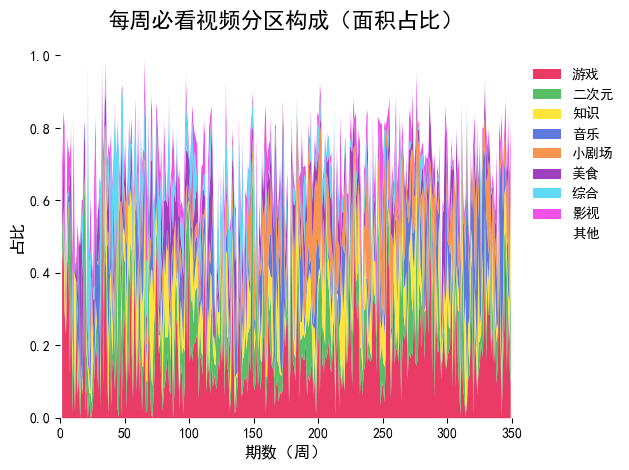

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# 1. 读数据
df = pd.read_csv(r'D:\DSAI\Project\Data\每周必看视频信息.csv',
                 usecols=['number','pid_name_v2','danmaku'])
df['pid_name_v2'] = df['pid_name_v2'].replace('其他', '综合')
weekly = df.groupby(['number','pid_name_v2'])['danmaku'].sum().unstack(fill_value=0)
weekly = weekly.div(weekly.sum(axis=1), axis=0)

# 2. 只保留 TOP-N，其余合并为“其他”
TOP = 8
top_tags = weekly.sum(axis=0).nlargest(TOP).index
weekly_top = weekly[top_tags]
weekly_top['其他'] = weekly.drop(columns=top_tags).sum(axis=1)
# 把“其他”移到最后（堆叠顺序 = 列顺序）
weekly_top = weekly_top[top_tags.tolist() + ['其他']]

# 3. 高对比配色：其他 = 纯白，其余高饱和
high_contrast = ['#e6194B', '#3cb44b', '#ffe119', '#4363d8', '#f58231',
                 '#911eb4', '#42d4f4', '#f032e6']
colors = high_contrast[:TOP] + ['#FFFFFF']   # 最后一位纯白

# 4. 绘图：纯白“其他”放最顶
plt.figure(figsize=(16, 6), dpi=300)
weekly_top.plot.area(stacked=True, color=colors, alpha=0.85, linewidth=0)
plt.title('每周必看视频分区构成（面积占比）', fontsize=16, pad=20)
plt.xlabel('期数（周）', fontsize=12)
plt.ylabel('占比', fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.xlim(0, 350)
plt.ylim(0, 1)
sns.despine(left=True, bottom=True)
plt.tight_layout()

# 5. 高清导出
plt.savefig(r'D:\DSAI\Project\每周分区占比.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from pathlib import Path

file = Path(r"D:/DSAI/Project/Data/期末：所有模型月度情感评分+经济指标.xlsx")
df = pd.read_excel(file)

date_col = 'month'
senti_col = '训练snownlp标题修正'


# 1. 先转 datetime，再排好序
df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values(date_col)

# 2. 把索引设成 DatetimeIndex（而不是 PeriodIndex）
df.set_index(date_col, inplace=True)
ts = df[senti_col]          # 现在 ts.index 是 DatetimeIndex，matplotlib 可识别

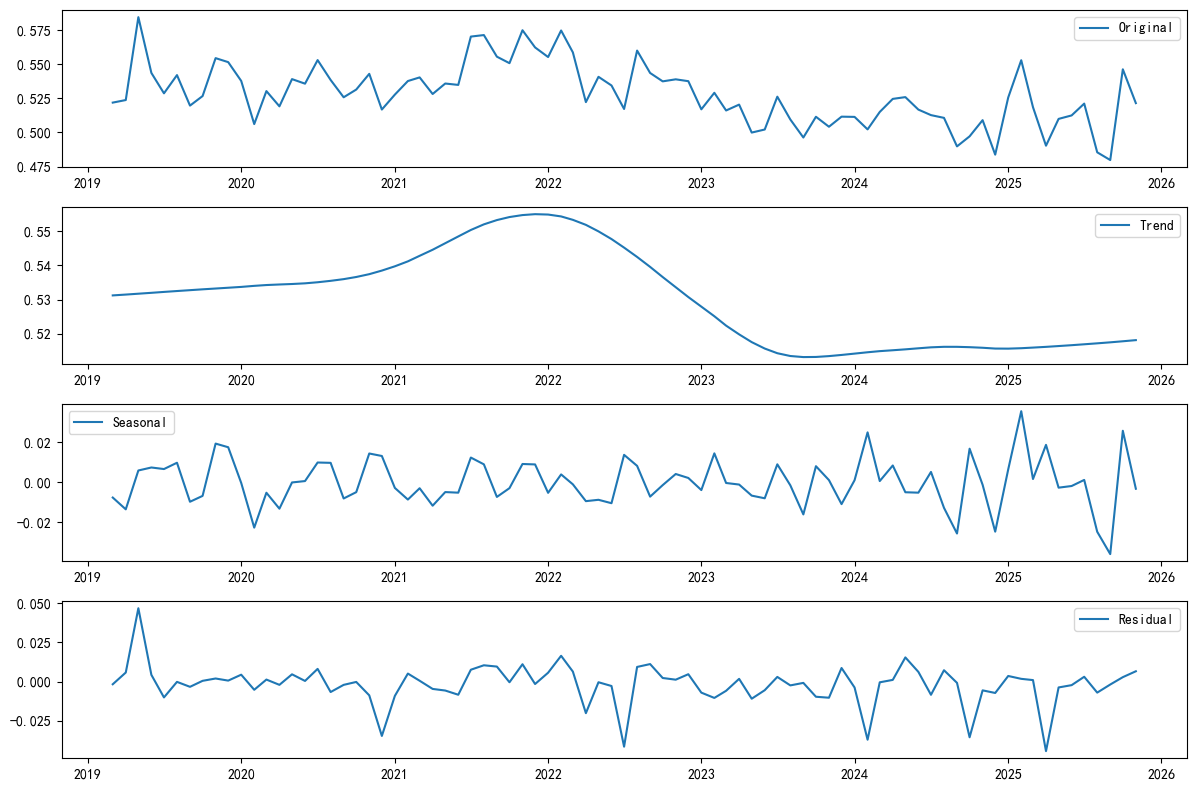

In [25]:
# 参数：period=12（月度），robust=True 可抵抗异常值
stl = STL(ts, period=12, robust=True)
res = stl.fit()

# 四件套
trend = res.trend
seasonal = res.seasonal
resid = res.resid

# 画图
plt.figure(figsize=(12,8))
plt.subplot(4,1,1)
plt.plot(ts, label='Original')
plt.legend()
plt.subplot(4,1,2)
plt.plot(trend, label='Trend')
plt.legend()
plt.subplot(4,1,3)
plt.plot(seasonal, label='Seasonal')
plt.legend()
plt.subplot(4,1,4)
plt.plot(resid, label='Residual')
plt.legend()
plt.tight_layout()
plt.show()

季节性强度 = 47.4%
趋势强度   = 53.9%
                            OLS Regression Results                            
Dep. Variable:          训练snownlp标题修正   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                 -0.078
Method:                 Least Squares   F-statistic:                    0.4708
Date:                Wed, 24 Dec 2025   Prob (F-statistic):              0.915
Time:                        16:35:32   Log-Likelihood:                 196.96
No. Observations:                  81   AIC:                            -369.9
Df Residuals:                      69   BIC:                            -341.2
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4877  

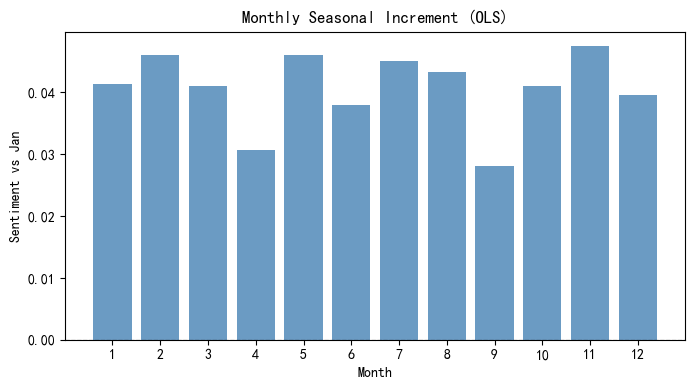

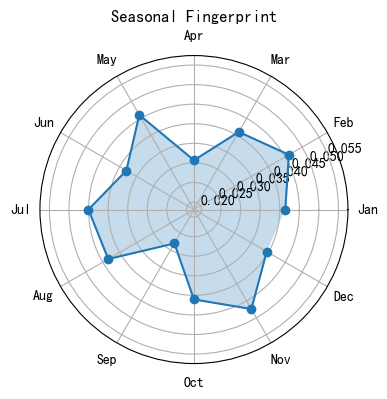

In [26]:
# -------------- 3.1 季节性 + 趋势强度 --------------
def strength(s, r):
    """s: 季节项, r: 残差项 -> 季节性强度"""
    return 1 - r.var() / (s.var() + r.var())

seasonal_strength = strength(seasonal, resid)
trend_strength    = strength(trend, resid)
print(f"季节性强度 = {seasonal_strength:.1%}")
print(f"趋势强度   = {trend_strength:.1%}")


# -------------- 3.2 月度虚拟回归 --------------
ts = ts.sort_index().astype(float)                 # 再保险一次
df_month = pd.get_dummies(ts.index.month, prefix='m').astype(float)
df_month.index = ts.index                          # 对齐！
X = sm.add_constant(df_month)
model = sm.OLS(ts, X).fit()
print(model.summary())

# -------------- 3.3 画图：柱状 + 雷达 --------------
coef = model.params[1:13]                  # 去掉 const，只留 m_1…m_12
months = np.arange(1, 13)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(months, coef.values, color='steelblue', alpha=0.8)
ax.axhline(0, color='k', ls='--', lw=0.8)
ax.set_xticks(months)
ax.set_xlabel('Month')
ax.set_ylabel('Sentiment vs Jan')
ax.set_title('Monthly Seasonal Increment (OLS)')

# 雷达图开关（想关就注释掉）
fig2 = plt.figure(figsize=(4,4))
ax2 = fig2.add_subplot(111, projection='polar')
theta = np.linspace(0, 2*np.pi, 12, endpoint=False)
ax2.plot(theta, coef.values, marker='o')
ax2.fill(theta, coef.values, alpha=0.25)
ax2.set_xticks(theta)
ax2.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec'])
ax2.set_ylim(coef.min()-0.01, coef.max()+0.01)
ax2.set_title('Seasonal Fingerprint')
plt.show()

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
import statsmodels.api as sm
from pathlib import Path

# 读取数据
file = Path(r"D:/DSAI/Project/Data/期末：所有模型月度情感评分+经济指标.xlsx")
df = pd.read_excel(file)

# 定义日期和情感评分列
date_col = 'month'
senti_cols = [
    'hh原始得分', 'hh中心化', 'snownlp原始得分', 'snownlp中心化', 'snownlp标题修正',
    '训练snownlp原始得分', '训练snownlp中心化', '训练snownlp标题修正',
    'svm原始得分', 'svm中心化', 'svm标题修正', 'nb原始得分', 'nb中心化', 'nb标题修正'
]

# 遍历每个情感评分模型
for senti_col in senti_cols:
    ts = df[[date_col, senti_col]].set_index(date_col)[senti_col].astype(float)
    
    # 确保索引是DatetimeIndex
    ts.index = pd.to_datetime(ts.index)
    
    # STL 分解
    stl = STL(ts, period=12, robust=True)
    res = stl.fit()
    seasonal = res.seasonal
    resid = res.resid
    
    # OLS 回归
    df_month = pd.get_dummies(ts.index.month, prefix='m').astype(float)
    df_month.index = ts.index  # 确保df_month的索引与ts的索引一致
    X = sm.add_constant(df_month)
    model = sm.OLS(ts, X).fit()
    coef = model.params[1:]  # 去掉常数项
    
    # 打印OLS回归结果
    print(f"\n{senti_col} OLS Regression Results:")
    print(model.summary())


hh原始得分 OLS Regression Results:
                            OLS Regression Results                            
Dep. Variable:                 hh原始得分   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                 -0.117
Method:                 Least Squares   F-statistic:                    0.2393
Date:                Wed, 24 Dec 2025   Prob (F-statistic):              0.994
Time:                        20:12:53   Log-Likelihood:                 164.60
No. Observations:                  81   AIC:                            -305.2
Df Residuals:                      69   BIC:                            -276.5
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.077

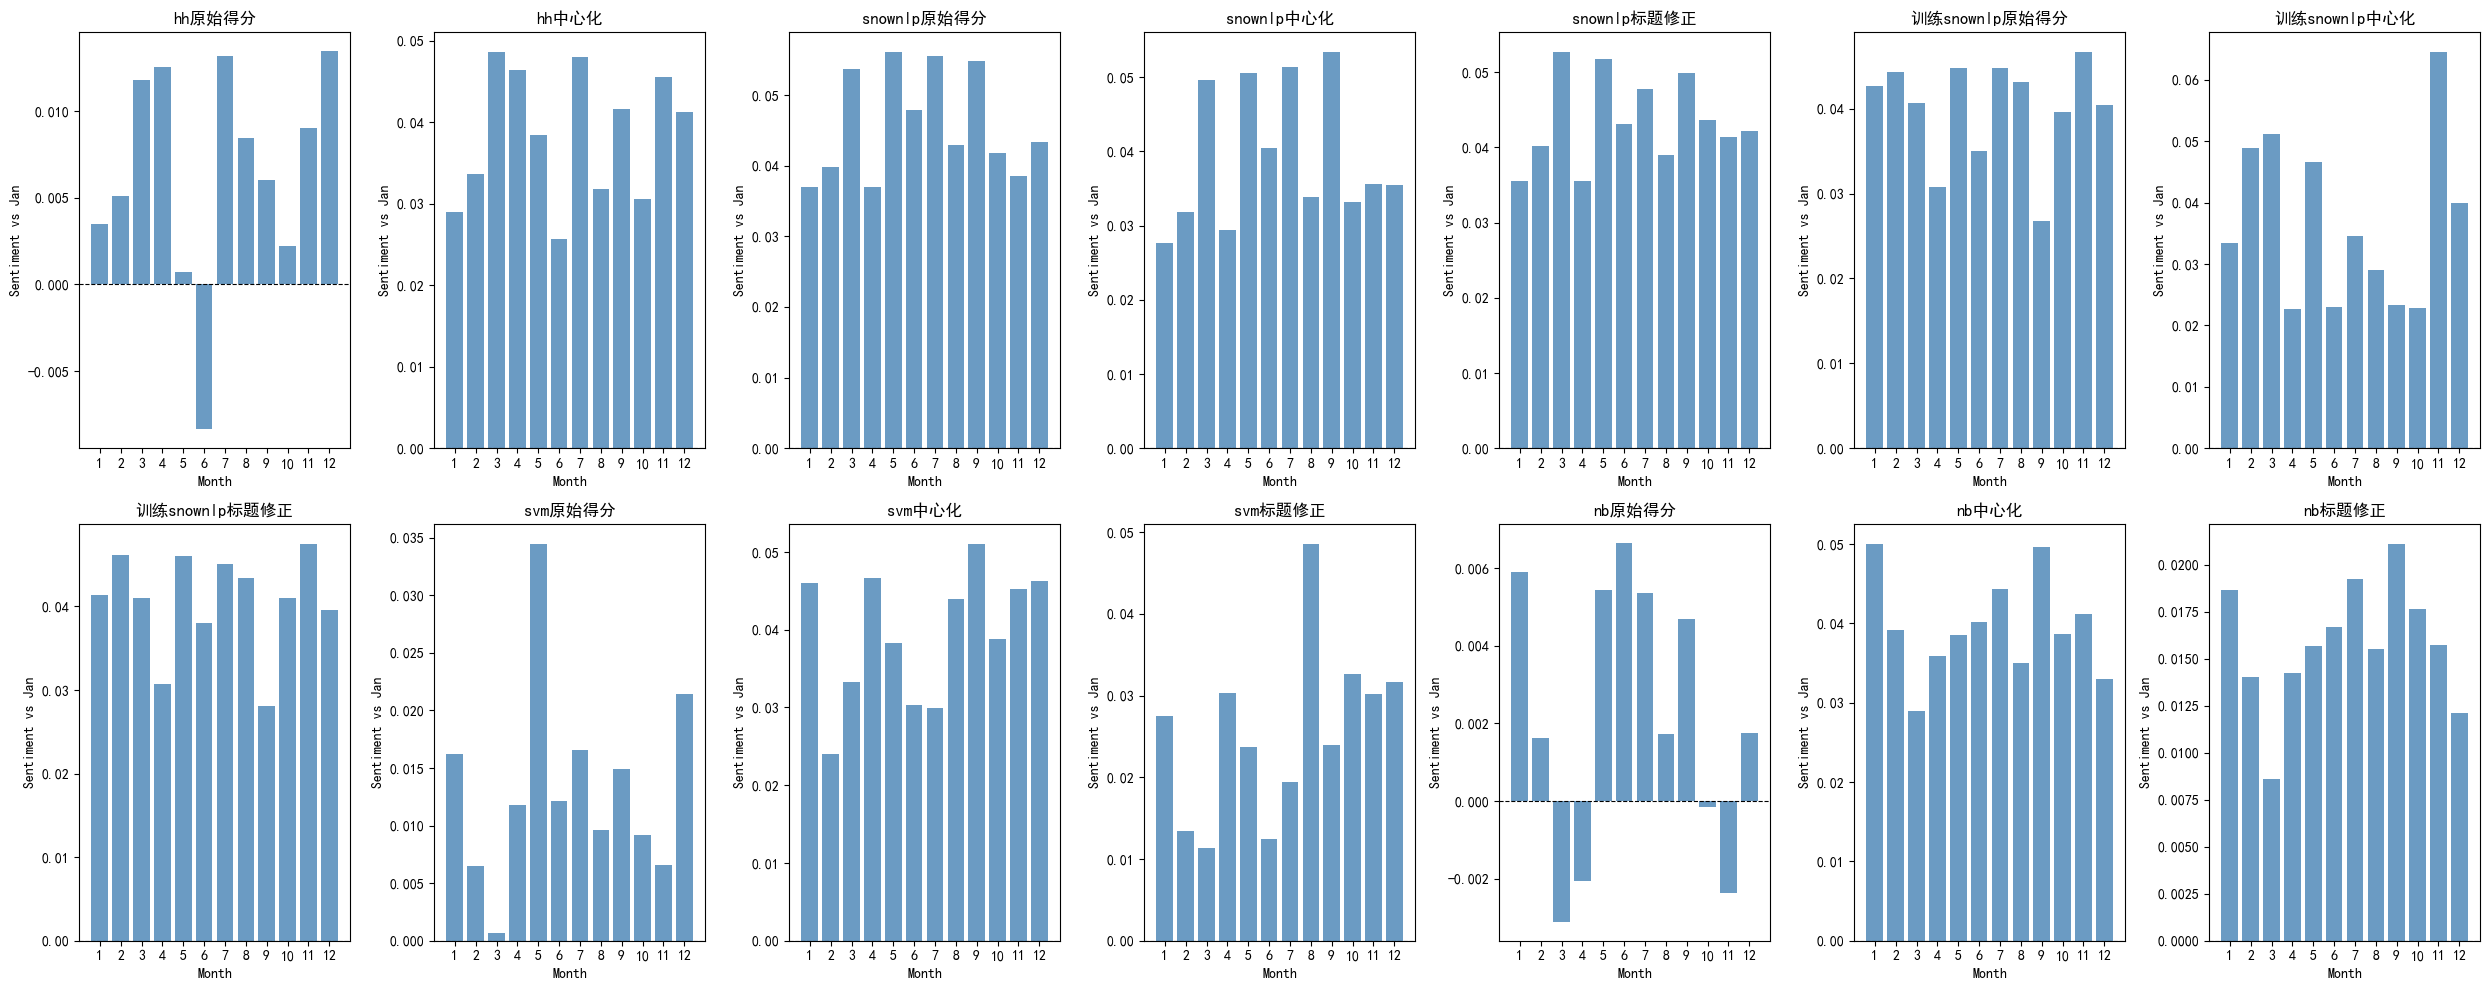

<Figure size 640x480 with 0 Axes>

In [43]:
# 初始化一个大图
fig, axes = plt.subplots(2, 7, figsize=(25, 10))  # 2行7列
axes = axes.flatten()  # 将axes数组展平

# 遍历每个情感评分模型
for i, senti_col in enumerate(senti_cols):
    ts = df[[date_col, senti_col]].set_index(date_col)[senti_col].astype(float)
    ts.index = pd.to_datetime(ts.index)
    
    # STL 分解
    stl = STL(ts, period=12, robust=True)
    res = stl.fit()
    seasonal = res.seasonal
    resid = res.resid
    
    # OLS 回归
    df_month = pd.get_dummies(ts.index.month, prefix='m').astype(float)
    df_month.index = ts.index  # 确保df_month的索引与ts的索引一致
    X = sm.add_constant(df_month)
    model = sm.OLS(ts, X).fit()
    coef = model.params[1:]  # 去掉常数项
    
    # 画图：Monthly Seasonal Increment (OLS)
    axes[i].bar(np.arange(1, 13), coef.values, color='steelblue', alpha=0.8)
    axes[i].axhline(0, color='k', ls='--', lw=0.8)
    axes[i].set_xticks(np.arange(1, 13))
    axes[i].set_xlabel('Month')
    axes[i].set_ylabel('Sentiment vs Jan')
    axes[i].set_title(f'{senti_col}')

# 调整布局
plt.tight_layout()
plt.show()

# 保存大图
plt.savefig(r'D:\DSAI\Project\OLS回归系数.png',dpi=300)

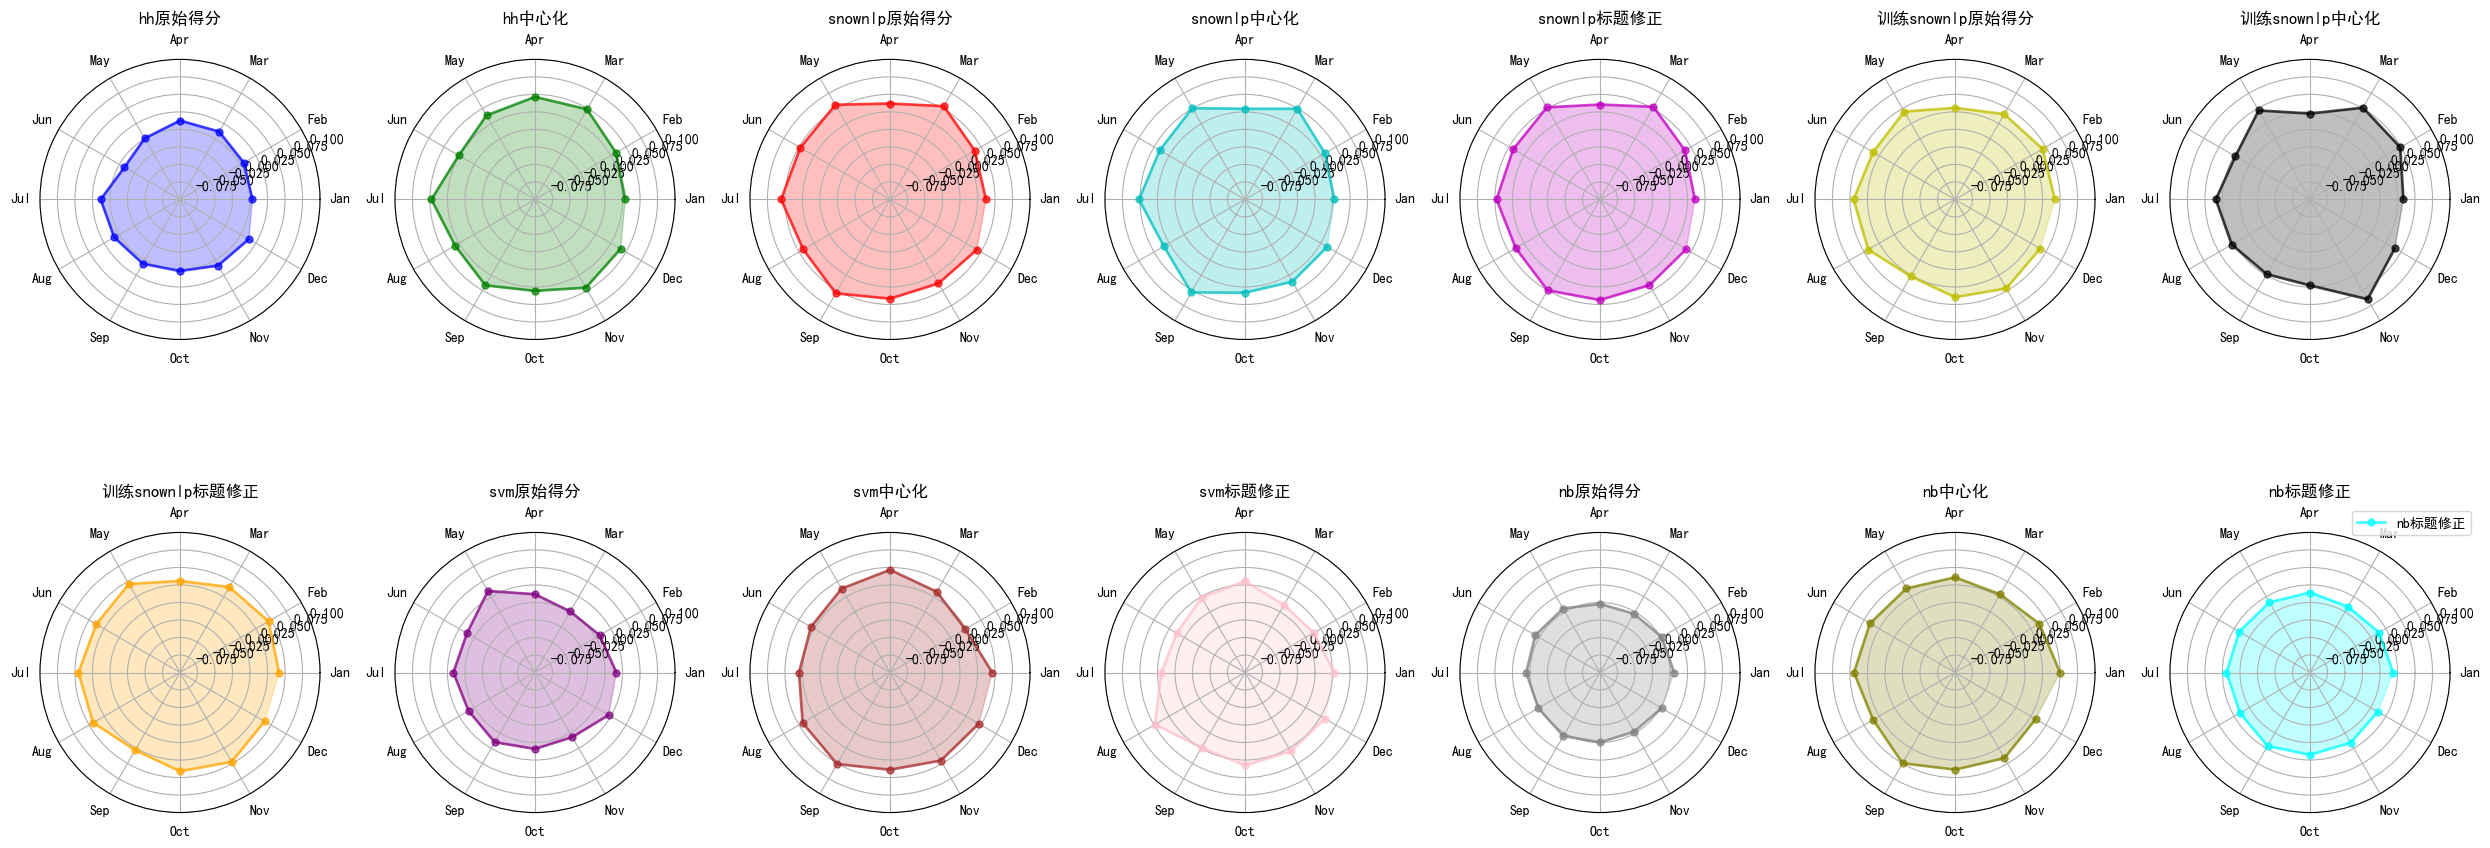

<Figure size 640x480 with 0 Axes>

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# 定义颜色和标签
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# 遍历每个情感评分模型
fig, axes = plt.subplots(2, 7, figsize=(25, 10), subplot_kw=dict(polar=True))  # 2行7列
axes = axes.flatten()  # 将axes数组展平

for i, senti_col in enumerate(senti_cols):
    ts = df[[date_col, senti_col]].set_index(date_col)[senti_col].astype(float)
    ts.index = pd.to_datetime(ts.index)
    
    # STL 分解
    stl = STL(ts, period=12, robust=True)
    res = stl.fit()
    
    # OLS 回归
    df_month = pd.get_dummies(ts.index.month, prefix='m').astype(float)
    df_month.index = ts.index  # 确保df_month的索引与ts的索引一致
    X = sm.add_constant(df_month)
    model = sm.OLS(ts, X).fit()
    coef = model.params[1:]  # 去掉常数项
    
    # 画图：Seasonal Fingerprint
    theta = np.linspace(0, 2 * np.pi, 12, endpoint=False)
    rad = coef.values
    axes[i].plot(theta, rad, color=colors[i % len(colors)], linewidth=2, linestyle='solid', marker='o', markersize=5, alpha=0.7, label=senti_col)
    axes[i].fill(theta, rad, color=colors[i % len(colors)], alpha=0.25)
    axes[i].set_xticks(theta)
    axes[i].set_xticklabels(labels)
    axes[i].set_ylim(-0.1, 0.1)
    axes[i].set_title(f'{senti_col}', va='bottom')

# 添加图例
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))

# 调整布局
plt.tight_layout()
plt.show()

# 保存大图
plt.savefig(r'D:\DSAI\Project\雷达图.png',dpi=300)

C:\Users\86180\AppData\Local\Temp\ipykernel_25796\394667955.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=word_freq.head(20), x="n", y="tokens", palette="viridis")


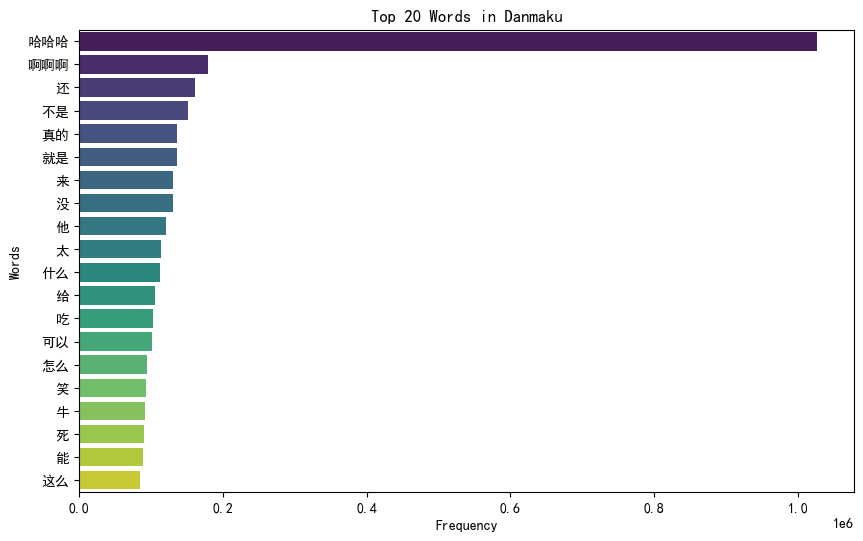

In [56]:
import jieba
import pandas as pd
import glob
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import platform

# 定义停用词表
stopwords = set(["啊", "哦", "哈","嗯", "额", "的", "了", "在", "是", "我", "有", "和", "就", "不", "人", "都","吗","吧","哈哈哈哈","呢","呀","哈哈","得","一个",
                 "一", "个", "这个","上", "也", "很", "到", "说", "要", "去", "你", "会", "着", "没有", "看", "好", "自己", "这"])

# 读取弹幕文件
def read_danmaku_files(folder_path):
    files = glob.glob(folder_path + "/**/*.txt", recursive=True)
    if not files:
        raise FileNotFoundError("没有找到任何 txt 文件，请检查路径")
    df = []
    for f in files:
        with open(f, encoding="utf-8") as file:
            text = file.read()
        # 只保留中文
        text = re.sub(r"[^\u4e00-\u9fa5]", "", text)
        df.append({"text": text})
    return pd.DataFrame(df)

# 中文分词并过滤停用词
def segment_cn(text):
    words = jieba.lcut(text)
    filtered_words = [word for word in words if word not in stopwords]
    return filtered_words

# 设置字体
if platform.system() == "Windows":
    plt.rcParams['font.family'] = 'SimHei'  # 黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 读取弹幕数据
danmaku_df = read_danmaku_files("D:/DSAI/Project/Data/每期弹幕")

# 分词
danmaku_df["tokens"] = danmaku_df["text"].apply(segment_cn)

# 统计词频
word_freq = danmaku_df.explode("tokens").groupby("tokens").size().reset_index(name="n")
word_freq = word_freq.sort_values(by="n", ascending=False)

# 绘制前20词频柱状图
plt.figure(figsize=(10, 6))
sns.barplot(data=word_freq.head(20), x="n", y="tokens", palette="viridis")
plt.title("Top 20 Words in Danmaku")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

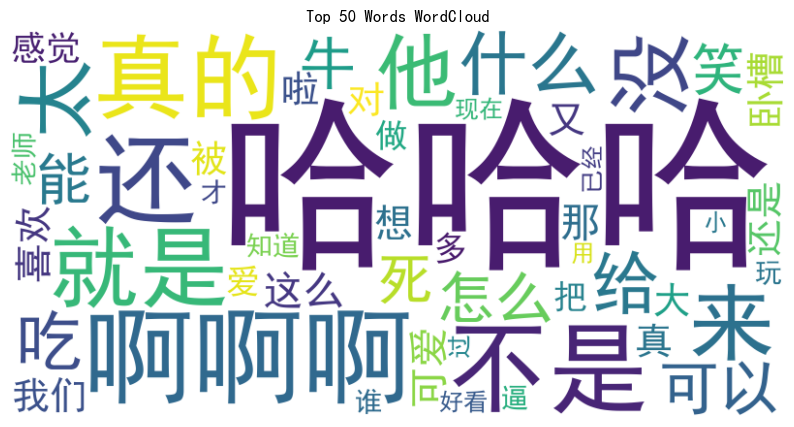

<Figure size 640x480 with 0 Axes>

In [57]:
# 绘制前50词的词云图
wordcloud = WordCloud(
    font_path="simhei.ttf",  # 设置字体路径
    background_color="white",  # 设置词云背景颜色
    max_words=50,  # 设置最多显示的词数
    width=800,  # 设置词云图宽度
    height=400  # 设置词云图高度
).generate_from_frequencies(word_freq.set_index("tokens")["n"].head(50))

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Top 50 Words WordCloud")
plt.show()
plt.savefig(r'D:\DSAI\Project\词云.png',dpi=1000)